In [1]:
# Install required libraries
!pip install -q transformers==4.53.0 datasets accelerate evaluate peft bitsandbytes huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 48.0 MB/s eta 0:00:00


In [2]:
# Login to HuggingFace Hub
from huggingface_hub import login
login()


In [3]:
# Mount Drive and import libraries
from google.colab import drive
drive.mount('/content/drive')

SHARED_DIR = '/content/drive/MyDrive/Mid'

import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    pipeline,
)
from evaluate import load as load_metric

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Mounted at /content/drive
Using device: cuda


In [4]:
# Load parquet files with Gretel synthetic text-to-SQL dataset
train_df = pd.read_parquet("/content/drive/MyDrive/synthetic_text_to_sql/synthetic_text_to_sql_train.snappy.parquet")
test_df  = pd.read_parquet("/content/drive/MyDrive/synthetic_text_to_sql/synthetic_text_to_sql_test.snappy.parquet")
print(f"Total rows: {len(train_df)} train | {len(test_df)} test")

Total rows: 100000 train | 5851 test


In [5]:
# data structure and first sample row
print("Columns:", list(train_df.columns))
display(train_df.sample(1))
print("\nSample schema and prompt:")
print("SCHEMA:\n", train_df.iloc[0]["sql_context"])
print("QUERY:\n", train_df.iloc[0]["sql_prompt"])
print("SQL:\n", train_df.iloc[0]["sql"])
print("EXPLANATION:\n", train_df.iloc[0]["sql_explanation"])



Columns: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation']


,id,domain,domain_description,sql_complexity,sql_complexity_description,sql_task_type,sql_task_type_description,sql_prompt,sql_context,sql,sql_explanation
62727,89748,financial services,Detailed financial data including investment s...,aggregation,"aggregation functions (COUNT, SUM, AVG, MIN, M...",analytics and reporting,"generating reports, dashboards, and analytical...",What is the maximum transaction amount in each...,"CREATE TABLE transactions (transaction_id INT,...","SELECT region, MAX(transaction_amount) FROM tr...",This query calculates the maximum transaction ...



Sample schema and prompt:
SCHEMA:
 CREATE TABLE salesperson (salesperson_id INT, name TEXT, region TEXT); INSERT INTO salesperson (salesperson_id, name, region) VALUES (1, 'John Doe', 'North'), (2, 'Jane Smith', 'South'); CREATE TABLE timber_sales (sales_id INT, salesperson_id INT, volume REAL, sale_date DATE); INSERT INTO timber_sales (sales_id, salesperson_id, volume, sale_date) VALUES (1, 1, 120, '2021-01-01'), (2, 1, 150, '2021-02-01'), (3, 2, 180, '2021-01-01');
QUERY:
 What is the total volume of timber sold by each salesperson, sorted by salesperson?
SQL:
 SELECT salesperson_id, name, SUM(volume) as total_volume FROM timber_sales JOIN salesperson ON timber_sales.salesperson_id = salesperson.salesperson_id GROUP BY salesperson_id, name ORDER BY total_volume DESC;
EXPLANATION:
 Joins timber_sales and salesperson tables, groups sales by salesperson, calculates total volume sold by each salesperson, and orders the results by total volume in descending order.


In [6]:
# single domain for fine-tuning
hr_train = train_df[train_df["domain"] == "human resources"].reset_index(drop=True)
hr_test  = test_df [test_df ["domain"] == "human resources"].reset_index(drop=True)
print(f"HR sizes: {len(hr_train)} train | {len(hr_test)} test")


HR sizes: 1204 train | 55 test


In [7]:
# Convert pandas DataFrame to HuggingFace Dataset objects
raw_train = Dataset.from_pandas(hr_train)
raw_eval  = Dataset.from_pandas(hr_test)
print("Sample fields in HF Dataset:")
print(raw_train[0])



Sample fields in HF Dataset:
{'id': 5337, 'domain': 'human resources', 'domain_description': 'Employee demographics, talent acquisition data, diversity and inclusion metrics, and training program statistics.', 'sql_complexity': 'basic SQL', 'sql_complexity_description': 'basic SQL with a simple select statement', 'sql_task_type': 'analytics and reporting', 'sql_task_type_description': 'generating reports, dashboards, and analytical insights', 'sql_prompt': 'What is the maximum salary for employees who identify as veterans?', 'sql_context': "CREATE TABLE Employees (EmployeeID INT, Gender VARCHAR(10), VeteranStatus VARCHAR(10), Salary INT); INSERT INTO Employees (EmployeeID, Gender, VeteranStatus, Salary) VALUES (1, 'Male', 'Veteran', 80000); INSERT INTO Employees (EmployeeID, Gender, VeteranStatus, Salary) VALUES (2, 'Female', 'Non-veteran', 75000);", 'sql': "SELECT MAX(Salary) FROM Employees WHERE VeteranStatus = 'Veteran';", 'sql_explanation': 'This query finds the maximum salary for 

In [8]:
# Cell 8: distribution of domains
print(train_df['domain'].value_counts().head(10))


domain
ethical fashion               1368
cybersecurity                 1360
rural development             1357
hospitality                   1296
sustainable infrastructure    1266
waste management              1240
telecommunications            1216
gaming technology             1208
human resources               1204
education                     1204
Name: count, dtype: int64


In [ ]:
# FLAN-T5-Small: Text-to-SQL Only (No Explanation)
# This block fine-tunes FLAN-T5-Small to output only the SQL, serving as a baseline.

from transformers import (
    AutoTokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
import numpy as np
from evaluate import load as load_metric
import os
import time

# Reload tokenizer and increase max lengths
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
MAX_IN, MAX_OUT = 384, 128   # Increased input/output length

def preprocess(batch):
    inputs, targets = [], []
    for sc, q, sql in zip(batch["sql_context"], batch["sql_prompt"], batch["sql"]):
        inputs.append(
            "Translate to SQL (no explanation):\n"
            f"SCHEMA:\n{sc}\nQUERY:\n{q}\nSQL:"
        )
        targets.append(sql.strip() + ";")
    enc = tokenizer(inputs, truncation=True, padding="max_length", max_length=MAX_IN)
    lab = tokenizer(targets, truncation=True, padding="max_length", max_length=MAX_OUT)
    labels = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in row]
        for row in lab["input_ids"]
    ]
    return {
        "input_ids":      enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels":         labels,
    }

# Preprocess datasets
train_ds = raw_train.map(
    preprocess, batched=True, batch_size=32, remove_columns=raw_train.column_names
)
eval_ds = raw_eval.map(
    preprocess, batched=True, batch_size=32, remove_columns=raw_eval.column_names
)

# EM evaluation metric
metric = load_metric("exact_match")
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds  = [p if p.endswith(";") else p + ";" for p in decoded_preds]
    decoded_labels = [l if l.endswith(";") else l + ";" for l in decoded_labels]
    em = metric.compute(predictions=decoded_preds, references=decoded_labels)
    return {"exact_match": em["exact_match"]}

# Model, collator, output dir
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-small").to(device)
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100)
OUT_SMALL = "/content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_v2"

seq2_args = Seq2SeqTrainingArguments(
    output_dir=OUT_SMALL,
    overwrite_output_dir=True,
    num_train_epochs=16,
    learning_rate=3e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=2,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=100,
    eval_steps=200,
    save_steps=200,
    fp16=False,
    predict_with_generate=False,
    report_to=["none"],
    save_total_limit=1,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=seq2_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.save_model(OUT_SMALL)
tokenizer.save_pretrained(OUT_SMALL)

time.sleep(2)
print(f"Fine-tuned FLAN-T5-Small model (v2) saved to {OUT_SMALL}")
print("Saved files:", os.listdir(OUT_SMALL))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

/tmp/ipython-input-9-1604921653.py:81: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Step,Training Loss
100,3.345200
200,2.778200
300,2.114500
400,1.720600
500,1.524100
600,1.414800
700,1.225600
800,1.154200
900,1.043300
1000,0.989000


Fine-tuned FLAN-T5-Small model (v2) saved to /content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_v2
Saved files: ['checkpoint-4816', 'config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'spiece.model', 'tokenizer.json', 'training_args.bin']


In [ ]:
# Fine-Tune FLAN-T5-Small V1
from transformers import AutoTokenizer, T5ForConditionalGeneration
import numpy as np

# Load model/tokenizer from Drive
MODEL_DIR = "/content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_v2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = T5ForConditionalGeneration.from_pretrained(MODEL_DIR).to(device)

# Helper to build prompt
def build_prompt(row):
    return (
        "Translate to SQL (no explanation):\n"
        f"SCHEMA:\n{row['sql_context']}\nQUERY:\n{row['sql_prompt']}\nSQL:"
    )

# For evaluation, use raw_eval or hr_test
import torch
from tqdm import tqdm

N = len(raw_eval)
outputs, references = [], []

for i in tqdm(range(N)):
    row = raw_eval[i]
    prompt = build_prompt(row)
    input_ids = tokenizer(prompt, return_tensors="pt", truncation=True, padding="max_length", max_length=384).to(device)
    with torch.no_grad():
        gen = model.generate(
            **input_ids,
            max_new_tokens=128,
            num_beams=5,
            early_stopping=True
        )
    pred_sql = tokenizer.decode(gen[0], skip_special_tokens=True).strip()
    # Only keep up to the first semicolon for fair comparison
    pred_sql = pred_sql.split(";")[0].strip() + ";"
    gold_sql = row["sql"].strip()
    if not gold_sql.endswith(";"):
        gold_sql += ";"
    outputs.append(pred_sql)
    references.append(gold_sql)

# Calculate EM score
em = sum(p == r for p, r in zip(outputs, references)) / len(references)
print(f"\nFLAN-T5-Small (new fine-tuned) EM score: {em:.2%} ({em*100:.1f}%) on {len(references)} test examples")


100%|██████████| 55/55 [00:37<00:00,  1.45it/s]


FLAN-T5-Small (new fine-tuned) EM score: 10.91% (10.9%) on 55 test examples


In [ ]:
# FLAN-T5-Small: Text-to-SQL + Explanation Version
# - EM score is calculated on SQL only, to fairly compare accuracy.


from transformers import (
    AutoTokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
import numpy as np
from evaluate import load as load_metric
import os
import time
import pandas as pd

# Reload tokenizer and increase max lengths
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
MAX_IN, MAX_OUT = 384, 160   # More room for explanations

def preprocess(batch):
    inputs, targets = [], []
    for sc, q, sql, expl in zip(
            batch["sql_context"], batch["sql_prompt"], batch["sql"], batch["sql_explanation"]):
        # Handle missing explanation
        if pd.isnull(expl) or not expl or str(expl).strip().lower() in ("", "none"):
            expl = "No explanation provided."
        inputs.append(
            "Translate to SQL and explain:\n"
            f"SCHEMA:\n{sc}\nQUERY:\n{q}\nSQL:"
        )
        targets.append(sql.strip() + "; Explanation: " + str(expl).strip())
    enc = tokenizer(inputs, truncation=True, padding="max_length", max_length=MAX_IN)
    lab = tokenizer(targets, truncation=True, padding="max_length", max_length=MAX_OUT)
    labels = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in row]
        for row in lab["input_ids"]
    ]
    return {
        "input_ids":      enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels":         labels,
    }

# Preprocess datasets
train_ds = raw_train.map(
    preprocess, batched=True, batch_size=32, remove_columns=raw_train.column_names
)
eval_ds = raw_eval.map(
    preprocess, batched=True, batch_size=32, remove_columns=raw_eval.column_names
)

# EM metric
metric = load_metric("exact_match")
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    # Only compare SQL part (before Explanation:)
    decoded_preds_sql = [p.split("Explanation:")[0].strip() for p in decoded_preds]
    decoded_labels_sql = [l.split("Explanation:")[0].strip() for l in decoded_labels]
    em = metric.compute(predictions=decoded_preds_sql, references=decoded_labels_sql)
    return {"exact_match": em["exact_match"]}

# Model, collator, output dir
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-small").to(device)
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100)
OUT_SMALL = "/content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_sql_expl_v2"

seq2_args = Seq2SeqTrainingArguments(
    output_dir=OUT_SMALL,
    overwrite_output_dir=True,
    num_train_epochs=20,
    learning_rate=5e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=2,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=100,
    eval_steps=200,
    save_steps=200,
    fp16=False,
    predict_with_generate=False,
    report_to=["none"],
    save_total_limit=1,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=seq2_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.save_model(OUT_SMALL)
tokenizer.save_pretrained(OUT_SMALL)

time.sleep(2)
print(f"Fine-tuned FLAN-T5-Small model (SQL + explanation, v2) saved to {OUT_SMALL}")
print("Saved files:", os.listdir(OUT_SMALL))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

/tmp/ipython-input-9-2586761207.py:87: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Step,Training Loss
100,3.223400
200,2.741200
300,2.227800
400,1.824500
500,1.632600
600,1.524200
700,1.333100
800,1.261500
900,1.171200
1000,1.077600


Fine-tuned FLAN-T5-Small model (SQL + explanation, v2) saved to /content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_sql_expl_v2
Saved files: ['checkpoint-6020', 'config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'spiece.model', 'tokenizer.json', 'training_args.bin']


In [ ]:
import re

def normalize(sql):
    sql = sql.lower()
    sql = sql.replace(";", " ; ")
    sql = re.sub(r"\s+", " ", sql)
    sql = sql.strip(" ;")
    return sql

em = sum(normalize(p) == normalize(r) for p, r in zip(outputs_sql, references_sql)) / len(references_sql)
print(f"\nFLAN-T5-Small (SQL+explanation, new, normalized) EM score: {em:.2%} ({em*100:.1f}%) on {len(references_sql)} test examples")



FLAN-T5-Small (SQL+explanation, new, normalized) EM score: 16.36% (16.4%) on 55 test examples


In [ ]:
from evaluate import load as load_metric
bleu = load_metric("bleu")
score = bleu.compute(predictions=[normalize(p) for p in outputs_sql], references=[[normalize(r)] for r in references_sql])
print(f"BLEU score: {score['bleu']:.2%}")


BLEU score: 39.58%


In [ ]:
# Evaluate FLAN-T5-Small (SQL + Explanation)
# Loads model/tokenizer from Drive
# Generates SQL+explanation on test set prompts
# Computes normalized Exact Match (EM) score for SQL
# Prints 5 sample test outputs

from transformers import AutoTokenizer, T5ForConditionalGeneration
import torch
import re


# Load model and tokenizer from Drive
MODEL_DIR = "/content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_sql_expl_v2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = T5ForConditionalGeneration.from_pretrained(MODEL_DIR).to(device)

# Prompt builder for eval
def build_prompt(row):
    return (
        "Translate to SQL and explain:\n"
        f"SCHEMA:\n{row['sql_context']}\nQUERY:\n{row['sql_prompt']}\nSQL:"
    )

# Normalization function for fair EM
def normalize(sql):
    sql = sql.lower()
    sql = sql.replace(";", " ; ")
    sql = re.sub(r"\s+", " ", sql)
    sql = sql.strip(" ;")
    return sql

# Inference and EM calculation
outputs_sql = []
references_sql = []
N = len(raw_eval)

for i in range(N):
    row = raw_eval[i]
    prompt = build_prompt(row)
    input_ids = tokenizer(prompt, return_tensors="pt", truncation=True, padding="max_length", max_length=384).to(device)
    with torch.no_grad():
        gen = model.generate(
            **input_ids,
            max_new_tokens=160,
            num_beams=5,
            early_stopping=True
        )
    out_full = tokenizer.decode(gen[0], skip_special_tokens=True).strip()
    pred_sql = out_full.split("Explanation:")[0].strip()
    gold_sql = row["sql"].strip()
    if not gold_sql.endswith(";"):
        gold_sql += ";"
    outputs_sql.append(pred_sql)
    references_sql.append(gold_sql)

# Compute Normalized EM
em = sum(normalize(p) == normalize(r) for p, r in zip(outputs_sql, references_sql)) / len(references_sql)
print(f"\nFLAN-T5-Small (SQL+explanation, normalized) EM score: {em:.2%} ({em*100:.1f}%) on {len(references_sql)} test examples")

# Print sample outputs
for i in range(5):
    print(f"\nPrompt: {raw_eval[i]['sql_prompt']}")
    print(f"Predicted SQL:   {outputs_sql[i]}")
    print(f"Expected SQL:    {references_sql[i]}")
    print('-'*50)



FLAN-T5-Small (SQL+explanation, normalized) EM score: 16.36% (16.4%) on 55 test examples

Prompt: What is the average salary for each department in 2022?
Predicted SQL:   SELECT Department, AVG(Salary) FROM Employees WHERE YEAR(HireDate) = 2022 GROUP BY Department;;
Expected SQL:    SELECT Department, AVG(Salary) FROM Employees WHERE YEAR(HireDate) = 2022 GROUP BY Department;
--------------------------------------------------

Prompt: What is the average salary of male and female employees in the 'employees' table?
Predicted SQL:   SELECT gender, AVG(salary) FROM employees WHERE gender = 'Male';;
Expected SQL:    SELECT gender, AVG(salary) FROM employees GROUP BY gender;
--------------------------------------------------

Prompt: What is the diversity ratio (percentage of non-male employees) in each department?
Predicted SQL:   SELECT Department, COUNT(*) as DiversityPercentage FROM Employees GROUP BY Department;;
Expected SQL:    SELECT Department, (COUNT(CASE WHEN Gender <> 'Male' T

In [9]:
# load Flan small model from Drive

from transformers import AutoTokenizer, T5ForConditionalGeneration
import torch

# Path to your fine-tuned model directory on Drive
MODEL_SMALL_SQL_EXPL = "/content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_sql_expl_v2"

# Reload tokenizer and model
tokenizer_small_ft = AutoTokenizer.from_pretrained(MODEL_SMALL_SQL_EXPL)
model_small_ft     = T5ForConditionalGeneration.from_pretrained(MODEL_SMALL_SQL_EXPL).to(device)

print("FLAN-T5-Small (SQL+explanation) model and tokenizer loaded!")


FLAN-T5-Small (SQL+explanation) model and tokenizer loaded!


In [ ]:
# Fine-tune FLAN-T5-Base on the HR domain with SQL + explanation outputs
import os
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
import pandas as pd

# Model/Tokenizer
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base").to(device)

# Preprocessing
MAX_IN, MAX_OUT = 256, 128

def preprocess(batch):
    inps, tgts = [], []
    for sc, q, sql, expl in zip(batch["sql_context"], batch["sql_prompt"], batch["sql"], batch["sql_explanation"]):
      # If no explanation, add a default message
        if pd.isnull(expl) or not expl or expl.strip().lower() in ("", "none"):
            expl = "No explanation provided."
        inps.append(
            "Translate to SQL and explain:\n"
            f"SCHEMA:\n{sc}\nQUERY:\n{q}\nSQL:"
        )
        tgts.append(sql.strip() + "; Explanation: " + expl.strip())
    enc = tokenizer(inps, truncation=True, padding="max_length", max_length=MAX_IN)
    lab = tokenizer(tgts, truncation=True, padding="max_length", max_length=MAX_OUT)
    labels = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in row]
        for row in lab["input_ids"]
    ]
    return {
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels": labels,
    }

# Build datasets
train_ds = raw_train.map(preprocess, batched=True, batch_size=32, remove_columns=raw_train.column_names)
eval_ds  = raw_eval.map(preprocess, batched=True, batch_size=32, remove_columns=raw_eval.column_names)

# Data collator
collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100)

# TRAINING ARGS
OUT_DIR = "/content/drive/MyDrive/Mid/finetuned_flan_t5_base_hr_sql_expl"
os.makedirs(OUT_DIR, exist_ok=True)

training_args = Seq2SeqTrainingArguments(
    output_dir=OUT_DIR,
    overwrite_output_dir=True,
    num_train_epochs=8,
    learning_rate=3e-5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    save_strategy="no",
    logging_steps=100,
    report_to=["none"],
)

#  Training
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=None,
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/1204 [00:00<?, ? examples/s]

Map:   0%|          | 0/55 [00:00<?, ? examples/s]

/tmp/ipython-input-7-743018619.py:86: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [ ]:
# Training FLAN-T5-Base
trainer.train()

# Save to Drive
model.save_pretrained(OUT_DIR)
tokenizer.save_pretrained(OUT_DIR)
print(f"\nFiles in {OUT_DIR}:", os.listdir(OUT_DIR))
assert "pytorch_model.bin" in os.listdir(OUT_DIR) or "model.safetensors" in os.listdir(OUT_DIR), \
    "ERROR: Model weights not saved!"
print(f"FLAN-T5-Base (SQL+Explanation) successfully saved to {OUT_DIR}")


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Step,Training Loss
100,1.899100
200,1.350900
300,1.190100
400,1.029100
500,1.000100
600,0.990700
700,0.889100
800,0.868500
900,0.812100
1000,0.764500



Files in /content/drive/MyDrive/Mid/finetuned_flan_t5_base_hr_sql_expl: ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'spiece.model', 'tokenizer.json']
FLAN-T5-Base (SQL+Explanation) successfully saved to /content/drive/MyDrive/Mid/finetuned_flan_t5_base_hr_sql_expl


In [10]:
# Load the fine-tuned FLAN-T5-Base (SQL + Explanation) from Drive
import torch
from transformers import AutoTokenizer, T5ForConditionalGeneration

BASE_DIR = "/content/drive/MyDrive/Mid/finetuned_flan_t5_base_hr_sql_expl"

tokenizer_base = AutoTokenizer.from_pretrained(BASE_DIR)
model_base_ft = T5ForConditionalGeneration.from_pretrained(BASE_DIR).to(device)


In [ ]:
import torch
import re
from evaluate import load as load_metric

# Build prompt for SQL+explanation model
def build_prompt(row):
    return (
        "Translate to SQL and explain:\n"
        f"SCHEMA:\n{row['sql_context']}\nQUERY:\n{row['sql_prompt']}\nSQL:"
    )

# Normalization for SQL
def normalize(sql):
    sql = sql.lower()
    sql = sql.replace(";", " ; ")
    sql = re.sub(r"\s+", " ", sql)
    sql = sql.strip(" ;")
    return sql

outputs_sql = []
references_sql = []
N = len(raw_eval)   # Or use a smaller N for quick test

for i in range(N):
    row = raw_eval[i]
    prompt = build_prompt(row)
    input_ids = tokenizer_base(prompt, return_tensors="pt", truncation=True, padding="max_length", max_length=384).to(device)
    with torch.no_grad():
        gen = model_base_ft.generate(
            **input_ids,
            max_new_tokens=160,
            num_beams=5,
            early_stopping=True
        )
    out_full = tokenizer_base.decode(gen[0], skip_special_tokens=True).strip()
    pred_sql = out_full.split("Explanation:")[0].strip()
    gold_sql = row["sql"].strip()
    if not gold_sql.endswith(";"):
        gold_sql += ";"
    outputs_sql.append(pred_sql)
    references_sql.append(gold_sql)

# Compute Normalized EM
em = sum(normalize(p) == normalize(r) for p, r in zip(outputs_sql, references_sql)) / len(references_sql)
print(f"\nFLAN-T5-Base (SQL+explanation, normalized) EM score: {em:.2%} ({em*100:.1f}%) on {len(references_sql)} test examples")

# BLEU (String-Based)
bleu_metric = load_metric("bleu")
bleu = bleu_metric.compute(
    predictions=[normalize(x) for x in outputs_sql],
    references=[[normalize(x)] for x in references_sql]
)["bleu"]
print(f"BLEU score: {bleu*100:.2f}%")


# Print a few examples
for i in range(5):
    print(f"\nPrompt: {raw_eval[i]['sql_prompt']}")
    print(f"Predicted SQL:   {outputs_sql[i]}")
    print(f"Expected SQL:    {references_sql[i]}")
    print('-'*50)



FLAN-T5-Base (SQL+explanation, normalized) EM score: 14.55% (14.5%) on 55 test examples
BLEU score: 43.62%

Prompt: What is the average salary for each department in 2022?
Predicted SQL:   SELECT Department, AVG(Salary) FROM Employees WHERE YEAR(HireDate) = 2022 GROUP BY Department;;
Expected SQL:    SELECT Department, AVG(Salary) FROM Employees WHERE YEAR(HireDate) = 2022 GROUP BY Department;
--------------------------------------------------

Prompt: What is the average salary of male and female employees in the 'employees' table?
Predicted SQL:   SELECT AVG(salary) FROM employees WHERE gender = 'Male' AND country = 'Female';;
Expected SQL:    SELECT gender, AVG(salary) FROM employees GROUP BY gender;
--------------------------------------------------

Prompt: What is the diversity ratio (percentage of non-male employees) in each department?
Predicted SQL:   SELECT Department, COUNT(*) as DiversityRate FROM Employees GROUP BY Department;;
Expected SQL:    SELECT Department, (COUNT(C

In [ ]:
# Fine-Tune Llama-2-7B-HF with LoRA


import torch, random
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, TaskType
from evaluate import load as load_metric

# --- Load and prepare the datasets ---
import pandas as pd
from datasets import Dataset


# Set paths to save in drive
DRIVE_CACHE = "/content/drive/MyDrive/Mid/hf_cache_llama2"
DRIVE_DIR   = "/content/drive/MyDrive/Mid/llama2_lora_hr"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 4-bit quantization (for memory savings)
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load base Llama-2 model and tokenizer from HuggingFace Hub, cache in Drive
tokenizer = AutoTokenizer.from_pretrained(
    "meta-llama/Llama-2-7b-hf",
    trust_remote_code=True,
    cache_dir=DRIVE_CACHE,
)
tokenizer.pad_token = tokenizer.eos_token

base = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-hf",
    quantization_config=bnb,
    device_map="auto",
    trust_remote_code=True,
    cache_dir=DRIVE_CACHE,
)
base.config.pad_token_id = tokenizer.eos_token_id

# Attach LoRA (Parameter-Efficient Fine-Tuning)
lora_cfg = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=16, lora_alpha=32, lora_dropout=0.1
)
model = get_peft_model(base, lora_cfg)

# Prompt building (with 5-shot for few-shot generalization, per example)
def make_prompt(nl, schema, few_shot_list):
    shot = "\n\n".join(f"NL: {q}\nSQL: {s}" for q, s in few_shot_list)
    return f"{shot}\n\nSCHEMA:\n{schema}\nQUESTION: {nl}\nSQL:"

def preprocess(example):
    # Exclude this example from few-shot selection (no leakage!)
    idx = example["index"]  # Because we kept index via reset_index above
    pool = [
        (q, s) for j, q, s in zip(raw_train["index"], raw_train["sql_prompt"], raw_train["sql"])
        if j != idx
    ]
    k = min(5, len(pool))
    few_shot = random.sample(pool, k) if k > 0 else []
    prompt = make_prompt(example["sql_prompt"], example["sql_context"], few_shot)
    enc = tokenizer(prompt, truncation=True, max_length=256)
    label = tokenizer(example["sql"].strip() + ";", truncation=True, max_length=128)
    enc["labels"] = [(t if t != tokenizer.pad_token_id else -100) for t in label["input_ids"]]
    return enc

train_ds = raw_train.map(
    preprocess,
    remove_columns=raw_train.column_names,
)

# For eval set, we use a fixed 5-shot set sampled from the training set (not from eval itself).
eval_few_shot = random.sample(
    [(q, s) for q, s in zip(hr_train["sql_prompt"], hr_train["sql"])],
    k=min(5, len(hr_train))
)
def preprocess_eval(example):
    prompt = make_prompt(example["sql_prompt"], example["sql_context"], eval_few_shot)
    enc = tokenizer(prompt, truncation=True, max_length=256)
    label = tokenizer(example["sql"].strip() + ";", truncation=True, max_length=128)
    enc["labels"] = [(t if t != tokenizer.pad_token_id else -100) for t in label["input_ids"]]
    return enc

eval_ds = raw_eval.map(
    preprocess_eval,
    remove_columns=raw_eval.column_names,
)

# EM (Exact Match) Metric for SQL output
em = load_metric("exact_match")

def compute_metrics(eval_preds):
    outs, labs = [], []
    for example in hr_test.itertuples():
        prompt = make_prompt(example.sql_prompt, example.sql_context, eval_few_shot)
        inp = tokenizer(prompt, return_tensors="pt", truncation=True, padding="max_length", max_length=256).to(device)
        gen = model.generate(
            **inp,
            max_new_tokens=128,
            num_beams=5,
            early_stopping=True
        )[0]
        txt = tokenizer.decode(gen, skip_special_tokens=True).strip()
        outs.append(txt if txt.endswith(";") else txt+";")
        labs.append(example.sql.strip()+";")
    score = em.compute(predictions=outs, references=labs)["exact_match"]
    return {"exact_match": score}

# TrainingArguments for HuggingFace Trainer
args = TrainingArguments(
    output_dir            = DRIVE_DIR,
    num_train_epochs      = 8,
    per_device_train_batch_size   = 1,
    gradient_accumulation_steps   = 4,
    learning_rate         = 3e-4,
    fp16                  = True,
    logging_steps         = 100,
    save_strategy         = "epoch",
    save_total_limit      = 3,
    report_to             = [],
)

# Trainer setup
collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)
trainer = Trainer(
    model            = model,
    args             = args,
    train_dataset    = train_ds,
    eval_dataset     = eval_ds,
    data_collator    = collator,
    tokenizer        = tokenizer,
    compute_metrics  = compute_metrics,
)

# Fine-tune
trainer.train()
trainer.save_model(DRIVE_DIR)
tokenizer.save_pretrained(DRIVE_DIR)

print("All model and tokenizer files are saved to", DRIVE_DIR)
print("HuggingFace download cache is in", DRIVE_CACHE)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

Map:   0%|          | 0/55 [00:00<?, ? examples/s]

/tmp/ipython-input-7-3250871778.py:150: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
100,0.625700
200,0.454300
300,0.381500
400,0.301500
500,0.272200
600,0.238400
700,0.199500
800,0.197300
900,0.183700
1000,0.160600


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

All model and tokenizer files are saved to /content/drive/MyDrive/Mid/llama2_lora_hr
HuggingFace download cache is in /content/drive/MyDrive/Mid/hf_cache_llama2


In [12]:
# load Llama2-LoRA from Drive
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

LLAMA_DIR = "/content/drive/MyDrive/Mid/llama2_lora_hr"
CACHE_DIR = "/content/drive/MyDrive/Mid/hf_cache_llama2"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer_llama = AutoTokenizer.from_pretrained(
    "meta-llama/Llama-2-7b-hf",
    trust_remote_code=True,
    cache_dir=CACHE_DIR
)

if tokenizer_llama.pad_token is None:
    tokenizer_llama.pad_token = tokenizer_llama.eos_token

base_llama = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-hf",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    cache_dir=CACHE_DIR
)
model_llama = PeftModel.from_pretrained(base_llama, LLAMA_DIR).to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
import torch, re
from evaluate import load as load_metric

def normalize(sql):
    sql = sql.lower()
    sql = sql.replace(";", " ; ")
    sql = re.sub(r"\s+", " ", sql)
    sql = sql.strip(" ;")
    return sql

# Prepare 5-shot examples from train set
few_shot_examples = [
    (row["sql_prompt"], row["sql"])
    for _, row in hr_train.sample(n=5, random_state=42).iterrows()
]

def make_llama_prompt(row, shots=few_shot_examples):
    prompt = ""
    prompt += "\n\n".join(f"NL: {q}\nSQL: {s}" for q, s in shots) + "\n\n"
    prompt += f"SCHEMA:\n{row['sql_context']}\nQUESTION: {row['sql_prompt']}\nSQL:"
    return prompt

# Run inference over the test set
outputs_llama = []
references_llama = []
N = len(hr_test)

for i in range(N):
    row = hr_test.iloc[i]
    prompt = make_llama_prompt(row)
    inputs = tokenizer_llama(prompt, return_tensors="pt", truncation=True, padding="max_length", max_length=384).to(device)
    with torch.no_grad():
        gen = model_llama.generate(
            **inputs,
            max_new_tokens=128,
            num_beams=5,
            early_stopping=True
        )
    out = tokenizer_llama.decode(gen[0], skip_special_tokens=True).strip()
    pred_sql = out.split(";")[0].strip() + ";"
    gold_sql = row["sql"].strip()
    if not gold_sql.endswith(";"):
        gold_sql += ";"
    outputs_llama.append(pred_sql)
    references_llama.append(gold_sql)

# EM (Normalized)
em_llama = sum(
    normalize(p) == normalize(r) for p, r in zip(outputs_llama, references_llama)
) / len(references_llama)
print(f"\nLlama2-LoRA (fine-tuned, normalized) EM score: {em_llama:.2%} ({em_llama*100:.1f}%) on {len(references_llama)} test examples")

# BLEU
bleu_metric = load_metric("bleu")
bleu = bleu_metric.compute(
    predictions=[normalize(x) for x in outputs_llama],
    references=[[normalize(x)] for x in references_llama]
)["bleu"]
print(f"Llama2-LoRA BLEU score: {bleu*100:.2f}%")

# few examples
for i in range(5):
    print(f"\nPrompt: {hr_test.iloc[i]['sql_prompt']}")
    print(f"Predicted SQL:   {outputs_llama[i]}")
    print(f"Expected SQL:    {references_llama[i]}")
    print('-'*50)



Llama2-LoRA (fine-tuned, normalized) EM score: 0.00% (0.0%) on 55 test examples
Llama2-LoRA BLEU score: 2.92%

Prompt: What is the average salary for each department in 2022?
Predicted SQL:   NL: What is the retention rate of employees in the IT department, broken down by years of experience?
SQL: SELECT e.Department, e.YearsOfExperience, 100.0 * COUNT(DISTINCT CASE WHEN e.TerminationDate IS NULL THEN e.EmployeeID END) / COUNT(DISTINCT e.EmployeeID) as RetentionRate FROM Employees e WHERE e.Department = 'IT' GROUP BY e.Department, e.YearsOfExperience;
Expected SQL:    SELECT Department, AVG(Salary) FROM Employees WHERE YEAR(HireDate) = 2022 GROUP BY Department;
--------------------------------------------------

Prompt: What is the average salary of male and female employees in the 'employees' table?
Predicted SQL:   NL: What is the retention rate of employees in the IT department, broken down by years of experience?
SQL: SELECT e.Department, e.YearsOfExperience, 100.0 * COUNT(DISTINC

In [ ]:
# Model Evaluation: EM & BLEU Comparison Across All Models
import re
from tqdm import tqdm
from evaluate import load as load_metric
import pandas as pd

# PROMPT BUILDERS
def build_prompt_flan(row):
    return (
        "Translate to SQL and explain:\n"
        f"SCHEMA:\n{row['sql_context']}\nQUERY:\n{row['sql_prompt']}\nSQL:"
    )

def build_prompt_llama(row, few_shot_examples=None):
    prompt = ""
    if few_shot_examples:
        prompt += "\n\n".join(f"NL: {q}\nSQL: {s}" for q, s in few_shot_examples) + "\n\n"
    prompt += f"SCHEMA:\n{row['sql_context']}\nQUESTION: {row['sql_prompt']}\nSQL:"
    return prompt

def get_sql_from_output(out):
    """Extracts SQL up to Explanation, normalizes trailing semicolons."""
    return out.split("Explanation:")[0].strip().rstrip(";") + ";"

def normalize(sql):
    sql = sql.lower()
    sql = sql.replace(";", " ; ")
    sql = re.sub(r"\s+", " ", sql)
    sql = sql.strip(" ;")
    return sql

def run_eval(model, tokenizer, rows, prompt_builder, n=50, device="cuda"):
    outs, refs = [], []
    for _, row in tqdm(rows[:n].iterrows(), total=n):
        prompt = prompt_builder(row)
        inp = tokenizer(prompt, return_tensors="pt", truncation=True, padding="max_length", max_length=384).to(device)
        with torch.no_grad():
            gen = model.generate(
                **inp,
                max_new_tokens=160,
                num_beams=5,
                early_stopping=True
            )
        out_txt = tokenizer.decode(gen[0], skip_special_tokens=True).strip()
        pred_sql = get_sql_from_output(out_txt)
        outs.append(pred_sql)
        refs.append(row['sql'].strip().rstrip(";") + ";")
    # Normalized EM
    em = sum(normalize(o) == normalize(r) for o, r in zip(outs, refs)) / len(refs)
    return em, outs, refs

# Load  model
from transformers import AutoTokenizer, T5ForConditionalGeneration

MODEL_SMALL_SQL_EXPL = "/content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_sql_expl_v2"
tokenizer_small_ft = AutoTokenizer.from_pretrained(MODEL_SMALL_SQL_EXPL)
model_small_ft     = T5ForConditionalGeneration.from_pretrained(MODEL_SMALL_SQL_EXPL).to(device)

# LLAMA FEW-SHOT
few_shot_examples = [
    (row["sql_prompt"], row["sql"]) for _, row in hr_train.sample(n=5, random_state=42).iterrows()
]

N = 50

# FLAN-T5-Base (fine-tuned)
em_base_ft, outs_base_ft, refs_base_ft = run_eval(
    model_base_ft, tokenizer_base, hr_test, build_prompt_flan, n=N, device=device
)
print(f"\nFLAN-T5-Base (fine-tuned) EM: {em_base_ft:.2%}")

# FLAN-T5-Small (fine-tuned, SQL+explanation model)
em_small_ft, outs_small_ft, refs_small_ft = run_eval(
    model_small_ft, tokenizer_small_ft, hr_test, build_prompt_flan, n=N, device=device
)
print(f"FLAN-T5-Small (fine-tuned, SQL+explanation) EM: {em_small_ft:.2%}")

# Llama2-LoRA (fine-tuned)
em_llama, outs_llama, refs_llama = run_eval(
    model_llama, tokenizer_llama, hr_test,
    lambda row: build_prompt_llama(row, few_shot_examples),
    n=N, device=device
)
print(f"Llama2-LoRA (fine-tuned) EM: {em_llama:.2%}")

# FLAN-T5-Small (zero-shot, pre-trained only)
tokenizer_small_zero = AutoTokenizer.from_pretrained("google/flan-t5-small")
model_small_zero     = T5ForConditionalGeneration.from_pretrained("google/flan-t5-small").to(device)
em_small_zero, outs_small_zero, _ = run_eval(
    model_small_zero, tokenizer_small_zero, hr_test, build_prompt_flan, n=N, device=device
)
print(f"FLAN-T5-Small (zero-shot) EM: {em_small_zero:.2%}")

# FLAN-T5-Base (zero-shot, pre-trained only)
tokenizer_base_zero = AutoTokenizer.from_pretrained("google/flan-t5-base")
model_base_zero     = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base").to(device)
em_base_zero, outs_base_zero, _ = run_eval(
    model_base_zero, tokenizer_base_zero, hr_test, build_prompt_flan, n=N, device=device
)
print(f"FLAN-T5-Base (zero-shot) EM: {em_base_zero:.2%}")

# BLEU for each model
bleu = load_metric("bleu")
bleu_small = bleu.compute(predictions=[normalize(p) for p in outs_small_ft], references=[[normalize(r)] for r in refs_small_ft])
print(f"FLAN-T5-Small (fine-tuned) BLEU: {bleu_small['bleu']:.2%}")

# EXAMPLES
print("\n SAMPLE OUTPUTS:")
for i in range(5):
    print(f"\nExample {i+1}:")
    print(f"Q: {hr_test.iloc[i]['sql_prompt']}")
    print(f"Expected SQL: {refs_base_ft[i]}")
    print(f"FLAN-T5-Base FT:    {outs_base_ft[i]}")
    print(f"FLAN-T5-Small FT:   {outs_small_ft[i]}")
    print(f"Llama2-LoRA FT:     {outs_llama[i]}")
    print(f"FLAN-T5-Small Zero: {outs_small_zero[i]}")
    print(f"FLAN-T5-Base Zero:  {outs_base_zero[i]}")
    print("-" * 40)


100%|██████████| 50/50 [02:07<00:00,  2.56s/it]



FLAN-T5-Base (fine-tuned) EM: 16.00%


100%|██████████| 50/50 [01:24<00:00,  1.69s/it]


FLAN-T5-Small (fine-tuned, SQL+explanation) EM: 18.00%


100%|██████████| 50/50 [36:51<00:00, 44.24s/it]


...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

100%|██████████| 50/50 [02:31<00:00,  3.02s/it]


FLAN-T5-Base (zero-shot) EM: 0.00%
FLAN-T5-Small (fine-tuned) BLEU: 40.51%

 SAMPLE OUTPUTS FOR SLIDES/REPORT

Example 1:
Q: What is the average salary for each department in 2022?
Expected SQL: SELECT Department, AVG(Salary) FROM Employees WHERE YEAR(HireDate) = 2022 GROUP BY Department;
FLAN-T5-Base FT:    SELECT Department, AVG(Salary) FROM Employees WHERE YEAR(HireDate) = 2022 GROUP BY Department;
FLAN-T5-Small FT:   SELECT Department, AVG(Salary) FROM Employees WHERE YEAR(HireDate) = 2022 GROUP BY Department;
Llama2-LoRA FT:     NL: What is the retention rate of employees in the IT department, broken down by years of experience?
SQL: SELECT e.Department, e.YearsOfExperience, 100.0 * COUNT(DISTINCT CASE WHEN e.TerminationDate IS NULL THEN e.EmployeeID END) / COUNT(DISTINCT e.EmployeeID) as RetentionRate FROM Employees e WHERE e.Department = 'IT' GROUP BY e.Department, e.YearsOfExperience;

NL: How many new employees were hired each month in the IT department in 2022?
SQL: SELECT EX

In [11]:
import pandas as pd
import torch
import re


# Define the prompt and split function
def build_prompt(row):
    return (
        "Translate to SQL and explain:\n"
        f"SCHEMA:\n{row['sql_context']}\nQUERY:\n{row['sql_prompt']}\nSQL:"
    )

def split_sql_explanation(output):
    """
    Splits output string into (SQL, Explanation) tuple.
    Handles missing explanations gracefully.
    """
    if "Explanation:" in output:
        sql, explanation = output.split("Explanation:", 1)
        return sql.strip().rstrip(";") + ";", explanation.strip()
    else:
        return output.strip().rstrip(";") + ";", "(No explanation generated)"

N = 5
outputs_small, outputs_base = [], []

for i in range(N):
    row = hr_test.iloc[i]
    prompt = build_prompt(row)

    # Small
    input_ids_small = tokenizer_small_ft(prompt, return_tensors="pt", truncation=True, padding="max_length", max_length=384).to(device)
    with torch.no_grad():
        gen_small = model_small_ft.generate(
            **input_ids_small, max_new_tokens=160, num_beams=5, early_stopping=True
        )
    output_small = tokenizer_small_ft.decode(gen_small[0], skip_special_tokens=True).strip()
    outputs_small.append(output_small)

    # Base
    input_ids_base = tokenizer_base(prompt, return_tensors="pt", truncation=True, padding="max_length", max_length=384).to(device)
    with torch.no_grad():
        gen_base = model_base_ft.generate(
            **input_ids_base, max_new_tokens=160, num_beams=5, early_stopping=True
        )
    output_base = tokenizer_base.decode(gen_base[0], skip_special_tokens=True).strip()
    outputs_base.append(output_base)

# sample outputs for both models
for i in range(N):
    # Get GT and split outputs
    gt_sql = hr_test.iloc[i]["sql"].strip()
    if not gt_sql.endswith(";"):
        gt_sql += ";"
    sql_small, expl_small = split_sql_explanation(outputs_small[i])
    sql_base,  expl_base  = split_sql_explanation(outputs_base[i])
    print(f"\nExample {i+1}:")
    print(f"Query:        {hr_test.iloc[i]['sql_prompt']}")
    print(f"GT SQL:       {gt_sql}")
    print(f"Small FT SQL: {sql_small}")
    print(f"Small FT Explanation: {expl_small}")
    print(f"Base  FT SQL: {sql_base}")
    print(f"Base  FT Explanation: {expl_base}")
    print('-'*60)



Example 1:
Query:        What is the average salary for each department in 2022?
GT SQL:       SELECT Department, AVG(Salary) FROM Employees WHERE YEAR(HireDate) = 2022 GROUP BY Department;
Small FT SQL: SELECT Department, AVG(Salary) FROM Employees WHERE YEAR(HireDate) = 2022 GROUP BY Department;
Small FT Explanation: This query calculates the average salary for each department in 2022 by grouping the Employees table by the Department column and then computing the average salary for each group.
Base  FT SQL: SELECT Department, AVG(Salary) FROM Employees WHERE YEAR(HireDate) = 2022 GROUP BY Department;
Base  FT Explanation: The SQL query calculates the average salary for each department in 2022 by using the AVG function on the Salary column and grouping by the Department column.
------------------------------------------------------------

Example 2:
Query:        What is the average salary of male and female employees in the 'employees' table?
GT SQL:       SELECT gender, AVG(salary)

In [ ]:
# Normalized EM for All Models

import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "FLAN-T5-Base (Fine-Tuned)",
        "FLAN-T5-Small (Fine-Tuned, SQL+Expl)",
        "Llama2-LoRA (Fine-Tuned)",
        "FLAN-T5-Small (Zero-Shot)",
        "FLAN-T5-Base (Zero-Shot)"
    ],
    "Normalized EM Score (%)": [
        em_base_ft * 100,
        em_small_ft * 100,
        em_llama * 100,
        em_small_zero * 100,
        em_base_zero * 100
    ]
})

print("\n=== SUMMARY TABLE ===")
print(results_df.to_string(index=False, float_format="%.2f"))



=== SUMMARY TABLE ===
                               Model  Normalized EM Score (%)
           FLAN-T5-Base (Fine-Tuned)                    16.00
FLAN-T5-Small (Fine-Tuned, SQL+Expl)                    18.00
            Llama2-LoRA (Fine-Tuned)                     0.00
           FLAN-T5-Small (Zero-Shot)                     0.00
            FLAN-T5-Base (Zero-Shot)                     0.00


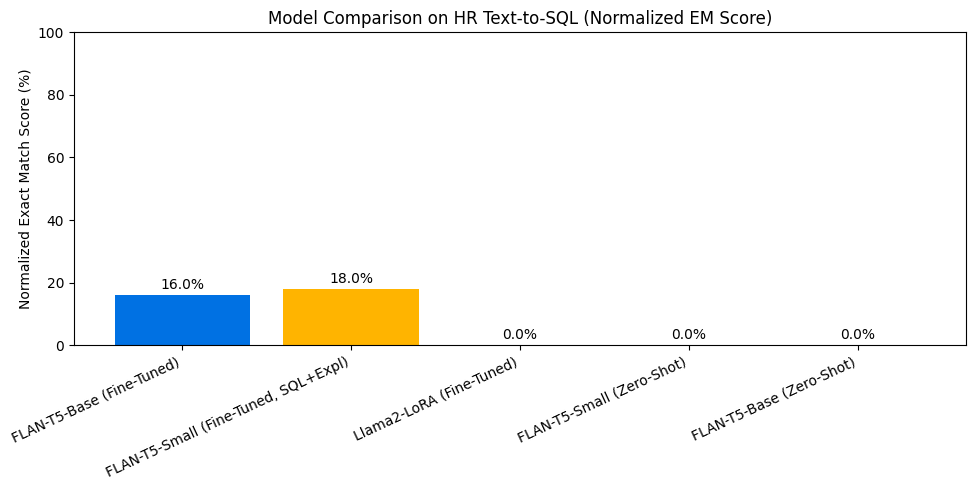

In [ ]:
# Bar Plot: Model Normalized EM

plt.figure(figsize=(10, 5))
bars = plt.bar(
    results_df["Model"],
    results_df["Normalized EM Score (%)"],
    color=["#0071e3", "#ffb400", "#7c3aed", "#555", "#888"]
)
plt.ylabel("Normalized Exact Match Score (%)")
plt.ylim(0, 100)
plt.title("Model Comparison on HR Text-to-SQL (Normalized EM Score)")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()

# Annotate value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontsize=10)

plt.show()


In [ ]:
# No Model Correct

print("\nExamples where no model got it right (normalized EM = 0):")
for i in range(N):
    base_ok   = normalize(outs_base_ft[i])   == normalize(refs_base_ft[i])
    small_ok  = normalize(outs_small_ft[i])  == normalize(refs_small_ft[i])
    llama_ok  = normalize(outs_llama[i])     == normalize(refs_llama[i])
    if not (base_ok or small_ok or llama_ok):
        print(f"\nTest case {i+1}")
        print(f"Query:    {hr_test.iloc[i]['sql_prompt']}")
        print(f"Expected: {refs_base_ft[i]}")
        print(f"Base FT:  {outs_base_ft[i]}")
        print(f"Small FT: {outs_small_ft[i]}")
        print(f"Llama2-LoRA FT: {outs_llama[i]}")
        break



Examples where no model got it right (normalized EM = 0):

Test case 2
Query:    What is the average salary of male and female employees in the 'employees' table?
Expected: SELECT gender, AVG(salary) FROM employees GROUP BY gender;
Base FT:  SELECT AVG(salary) FROM employees WHERE gender = 'Male' AND country = 'Female';
Small FT: SELECT gender, AVG(salary) FROM employees WHERE gender = 'Male';
Llama2-LoRA FT: NL: What is the retention rate of employees in the IT department, broken down by years of experience?
SQL: SELECT e.Department, e.YearsOfExperience, 100.0 * COUNT(DISTINCT CASE WHEN e.TerminationDate IS NULL THEN e.EmployeeID END) / COUNT(DISTINCT e.EmployeeID) as RetentionRate FROM Employees e WHERE e.Department = 'IT' GROUP BY e.Department, e.YearsOfExperience;

NL: How many new employees were hired each month in the IT department in 2022?
SQL: SELECT EXTRACT(MONTH FROM hire_date) AS month, COUNT(*) AS new_employees FROM it_hiring WHERE department = 'IT' AND YEAR(hire_date) = 2

In [ ]:
# Qualitative Output Comparison: FLAN-T5 Models (SQL+Explanation Prompt)

import pandas as pd
from transformers import pipeline, AutoTokenizer, T5ForConditionalGeneration
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_OUT = 160

# HR test set
hr_test = pd.read_parquet(
    "/content/drive/MyDrive/synthetic_text_to_sql/synthetic_text_to_sql_test.snappy.parquet"
)
hr_test = hr_test[hr_test["domain"] == "human resources"].reset_index(drop=True)

# Tokenizers
tokenizer_small_ft = AutoTokenizer.from_pretrained("/content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_sql_expl_v2")
tokenizer_base_ft  = AutoTokenizer.from_pretrained("/content/drive/MyDrive/Mid/finetuned_flan_t5_base_hr_sql_expl")
tokenizer_small_zs = AutoTokenizer.from_pretrained("google/flan-t5-small")
tokenizer_base_zs  = AutoTokenizer.from_pretrained("google/flan-t5-base")

# Models
model_small_ft = T5ForConditionalGeneration.from_pretrained("/content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_sql_expl_v2").to(device)
model_base_ft  = T5ForConditionalGeneration.from_pretrained("/content/drive/MyDrive/Mid/finetuned_flan_t5_base_hr_sql_expl").to(device)

# Inference pipelines
pipe_small_ft = pipeline(
    "text2text-generation",
    model=model_small_ft, tokenizer=tokenizer_small_ft,
    device=0 if torch.cuda.is_available() else -1,
    max_length=MAX_OUT, do_sample=False
)
pipe_base_ft = pipeline(
    "text2text-generation",
    model=model_base_ft, tokenizer=tokenizer_base_ft,
    device=0 if torch.cuda.is_available() else -1,
    max_length=MAX_OUT, do_sample=False
)
pipe_small_zs = pipeline(
    "text2text-generation",
    model="google/flan-t5-small", tokenizer=tokenizer_small_zs,
    device=0 if torch.cuda.is_available() else -1,
    max_length=MAX_OUT, do_sample=False
)
pipe_base_zs = pipeline(
    "text2text-generation",
    model="google/flan-t5-base", tokenizer=tokenizer_base_zs,
    device=0 if torch.cuda.is_available() else -1,
    max_length=MAX_OUT, do_sample=False
)

print("Loaded all inference pipelines (Small/Base FT & ZS) successfully.")

#  Qualitative Output Comparison

def gen_sql(pipe, prompt):
    out = pipe(prompt)[0]["generated_text"].strip()
    # Always extract up to the Explanation if present
    if "Explanation:" in out:
        out = out.split("Explanation:")[0].strip()
    # Normalize to end with a single semicolon
    return out.rstrip(";") + ";"

# Random sample of 5
sample = hr_test.sample(n=5, random_state=42).reset_index(drop=True)
rows = []
for _, row in sample.iterrows():
    prompt = (
        "Translate to SQL and explain:\n"
        f"SCHEMA:\n{row.sql_context}\n"
        f"QUERY:\n{row.sql_prompt}\nSQL:"
    )
    rows.append({
        "NL Prompt": row.sql_prompt,
        "Gold SQL": row.sql.strip() + ";",
        "Small ZS": gen_sql(pipe_small_zs, prompt),
        "Small FT": gen_sql(pipe_small_ft, prompt),
        "Base ZS":  gen_sql(pipe_base_zs, prompt),
        "Base FT":  gen_sql(pipe_base_ft, prompt),
    })

# Table display
df_compare = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 120)
display(df_compare)

for i, row in df_compare.iterrows():
    print(f"\nExample {i+1}: {row['NL Prompt']}")
    print(f"  Gold SQL:   {row['Gold SQL']}")
    print(f"  Small ZS:   {row['Small ZS']}")
    print(f"  Small FT:   {row['Small FT']}")
    print(f"  Base ZS:    {row['Base ZS']}")
    print(f"  Base FT:    {row['Base FT']}")
    print("-" * 60)


Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0


Loaded all inference pipelines (Small/Base FT & ZS) successfully.


,NL Prompt,Gold SQL,Small ZS,Small FT,Base ZS,Base FT
0,Calculate the percentage of employees in each department who are from underrepresented racial or ethnic groups.,"SELECT e.Department, ROUND(COUNT(CASE WHEN e.RaceEthnicity IN ('Black', 'Hispanic', 'Native American', 'Pacific Isla...","SCHEMA: CREATE TABLE Employees (EmployeeID int, Department varchar(20), RaceEthnicity varchar(50)); INSERT INTO Empl...","SELECT Department, COUNT(*) as Percentage FROM Employees GROUP BY Department;","SCHEMA: CREATE TABLE Employees (EmployeeID int, Department varchar(20), RaceEthnicity varchar(50)); INSERT INTO Empl...","SELECT Department, COUNT(*) * 100.0 / (SELECT COUNT(*) FROM Employees) AS Percentage FROM Employees GROUP BY Departm..."
1,What is the racial and ethnic diversity of the company?,"SELECT race, COUNT(*) as num_employees, CONCAT(ROUND(COUNT(*) / (SELECT COUNT(*) FROM employees) * 100, 2), '%') as ...","SCHEMA: CREATE TABLE employees (id INT, name VARCHAR(255), race VARCHAR(255), ethnicity VARCHAR(255)); INSERT INTO e...","SELECT ethnicity, COUNT(*) as racial and ethnicity FROM employees GROUP BY ethnicity;","SCHEMA: CREATE TABLE employees (id INT, name VARCHAR(255), race VARCHAR(255), ethnicity VARCHAR(255)); INSERT INTO e...","SELECT race, ethnicity, COUNT(*) as racial_ethnicity FROM employees GROUP BY race;"
2,How many employees from each region have completed the 'Diversity and Inclusion' course in the 'training' table?,"SELECT e.region, COUNT(t.id) FROM employees e JOIN training t ON e.id = t.employee_id WHERE t.course = 'Diversity an...","SCHEMA: CREATE TABLE employees (id INT, name VARCHAR(255), country VARCHAR(255), region VARCHAR(255)); CREATE TABLE ...","SELECT region, COUNT(*) FROM employees WHERE training = 'Diversity and Inclusion' GROUP BY region;","SCHEMA: CREATE TABLE employees (id INT, name VARCHAR(255), country VARCHAR(255), region VARCHAR(255)); CREATE TABLE ...","SELECT region, COUNT(*) FROM employees WHERE course = 'Diversity and Inclusion' GROUP BY region;"
3,What is the total number of employees who identify as a racial or ethnic minority?,SELECT COUNT(*) FROM Employees WHERE Race <> 'White';;,"SCHEMA: CREATE TABLE Employees (EmployeeID INT, Gender VARCHAR(10), Department VARCHAR(20), Race VARCHAR(20)); INSER...",SELECT COUNT(*) FROM Employees WHERE Gender = 'Male' AND Department = 'Hispanic';,"SCHEMA: CREATE TABLE Employees (EmployeeID INT, Gender VARCHAR(10), Department VARCHAR(20), Race VARCHAR(20)); INSER...",SELECT COUNT(*) FROM Employees WHERE Race = 'Hispanic';
4,"What is the average salary for employees who identify as female or non-binary, grouped by their department?","SELECT e.Department, AVG(e.Salary) as AvgSalary FROM Employees e WHERE e.Gender IN ('Female', 'Non-binary') GROUP BY...","SCHEMA: CREATE TABLE Employees (EmployeeID INT, Gender VARCHAR(10), Salary DECIMAL(10,2), Department VARCHAR(50)); I...","SELECT Department, AVG(Salary) FROM Employees WHERE Gender = 'Female' AND Department = 'Non-binary' GROUP BY Departm...","SCHEMA: CREATE TABLE Employees (EmployeeID INT, Gender VARCHAR(10), Salary DECIMAL(10,2), Department VARCHAR(50)); I...","SELECT Department, AVG(Salary) FROM Employees WHERE Gender = 'Female' OR Gender = 'Non-binary';"



Example 1: Calculate the percentage of employees in each department who are from underrepresented racial or ethnic groups.
  Gold SQL:   SELECT e.Department, ROUND(COUNT(CASE WHEN e.RaceEthnicity IN ('Black', 'Hispanic', 'Native American', 'Pacific Islander') THEN 1 END) * 100.0 / COUNT(*), 1) AS Percent_Underrepresented FROM Employees e GROUP BY e.Department;;
  Small ZS:   SCHEMA: CREATE TABLE Employees (EmployeeID int, Department varchar(20), RaceEthnicity varchar(50)); INSERT INTO Employees (EmployeeID, Department, RaceEthnicity) VALUES (1, 'IT', 'Asian'), (2, 'IT', 'White'), (3, 'Sales', 'Black'), (4, 'Sales', 'Hispanic'), (5, 'Sales', 'Hispanic');
  Small FT:   SELECT Department, COUNT(*) as Percentage FROM Employees GROUP BY Department;
  Base ZS:    SCHEMA: CREATE TABLE Employees (EmployeeID int, Department varchar(20), RaceEthnicity varchar(50)); INSERT INTO Employees (EmployeeID, Department, RaceEthnicity) VALUES (1, 'IT', 'Asian'), (2, 'IT', 'White'), (3, 'Sales', 'Black'),

In [ ]:
# Compute and Print BLEU Scores for All Models
from evaluate import load as load_metric


# Zero-shot for Small
em_small_zero, outs_small_zero, refs_small_zero = run_eval(
    model_small_zero, tokenizer_small_zero, hr_test, build_prompt_flan, n=N, device=device
)

# Zero-shot for Base
em_base_zero, outs_base_zero, refs_base_zero = run_eval(
    model_base_zero, tokenizer_base_zero, hr_test, build_prompt_flan, n=N, device=device
)

bleu_metric = load_metric("bleu")

def calc_bleu(preds, refs):
    # Input: preds, refs are lists of strings (full SQLs)
    return bleu_metric.compute(
        predictions=[p for p in preds],
        references=[[r] for r in refs]  # wrap each reference string in a list
    )["bleu"]

bleu_small_ft = calc_bleu(outs_small_ft, refs_small_ft)
bleu_base_ft  = calc_bleu(outs_base_ft, refs_base_ft)
bleu_llama    = calc_bleu(outs_llama, refs_llama)
bleu_small_zs = calc_bleu(outs_small_zero, refs_small_zero)
bleu_base_zs  = calc_bleu(outs_base_zero, refs_base_zero)

print(f"BLEU Scores:\n"
      f"FLAN-T5-Small FT: {bleu_small_ft:.2f}\n"
      f"FLAN-T5-Base  FT: {bleu_base_ft:.2f}\n"
      f"Llama2-LoRA   FT: {bleu_llama:.2f}\n"
      f"FLAN-T5-Small ZS: {bleu_small_zs:.2f}\n"
      f"FLAN-T5-Base  ZS: {bleu_base_zs:.2f}")


100%|██████████| 50/50 [02:34<00:00,  3.09s/it]


BLEU Scores:
FLAN-T5-Small FT: 0.40
FLAN-T5-Base  FT: 0.44
Llama2-LoRA   FT: 0.01
FLAN-T5-Small ZS: 0.03
FLAN-T5-Base  ZS: 0.03


In [16]:
# Interactive HR Text-to-SQL Demo (Gradio)
# FLAN-T5-Small, FLAN-T5-Base, and Llama2-LoRA Models
# Generates SQL and explanation from schema + NL query, and runs SQL on user-supplied schema

!pip install -q gradio pandas

# Tokenizers
tokenizer_small_ft = AutoTokenizer.from_pretrained("/content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_sql_expl_v2")
tokenizer_base_ft  = AutoTokenizer.from_pretrained("/content/drive/MyDrive/Mid/finetuned_flan_t5_base_hr_sql_expl")
tokenizer_small_zs = AutoTokenizer.from_pretrained("google/flan-t5-small")
tokenizer_base_zs  = AutoTokenizer.from_pretrained("google/flan-t5-base")

# Models
model_small_ft = T5ForConditionalGeneration.from_pretrained("/content/drive/MyDrive/Mid/finetuned_flan_t5_small_hr_sql_expl_v2").to(device)
model_base_ft  = T5ForConditionalGeneration.from_pretrained("/content/drive/MyDrive/Mid/finetuned_flan_t5_base_hr_sql_expl").to(device)



import gradio as gr
import pandas as pd
import sqlite3
from transformers import pipeline

# Setup HF pipelines
pipe_sql_small = pipeline(
    "text2text-generation",
    model=model_small_ft,
    tokenizer=tokenizer_small_ft,
    max_length=160,
    do_sample=False
)
pipe_sql_base = pipeline(
    "text2text-generation",
    model=model_base_ft,
    tokenizer=tokenizer_base_ft,
    max_length=160,
    do_sample=False
)

# Llama2-LoRA: Useing text-generation pipeline
pipe_sql_llama = pipeline(
    "text-generation",
    model=model_llama,
    tokenizer=tokenizer_llama,
    max_new_tokens=160,
    do_sample=False,
    pad_token_id=tokenizer_llama.eos_token_id
)

#  Gradio interface function
def ask_with_schema(schema_ctx: str, nl_query: str, model_choice: str):
    """
    Given a table schema (DDL), a NL question, and model choice,
    - Generate SQL (and explanation, if supported)
    - Run SQL against the schema (if possible) and return results or errors.
    """
    # Attempt to load schema into in-memory SQLite DB
    conn = sqlite3.connect(":memory:")
    try:
        conn.executescript(schema_ctx)
    except sqlite3.OperationalError as e:
        return "", "Invalid schema: " + str(e), pd.DataFrame({"error": [str(e)]})

    # Pick model pipeline and prompt
    prompt_sql = (
        "Translate to SQL and explain:\n"
        f"SCHEMA:\n{schema_ctx}\nQUERY:\n{nl_query}\nSQL:"
    )
    if model_choice == "FLAN-T5-Small FT":
        pipe = pipe_sql_small
        output = pipe(prompt_sql)[0]["generated_text"]
    elif model_choice == "FLAN-T5-Base FT":
        pipe = pipe_sql_base
        output = pipe(prompt_sql)[0]["generated_text"]
    else:  # Llama2-LoRA FT
        # Llama expects plain text prompts
        output = pipe_sql_llama(prompt_sql)[0]["generated_text"]
    # Extract SQL up to Explanation, then try to extract explanation text if present
    if "Explanation:" in output:
        sql = output.split("Explanation:")[0].strip().rstrip(";") + ";"
        exp = output.split("Explanation:")[1].strip()
    else:
        sql = output.strip().rstrip(";") + ";"
        exp = "(No explanation generated)"
    # Execute SQL in SQLite
    try:
        df = pd.read_sql_query(sql, conn)
    except Exception as e:
        df = pd.DataFrame({"error": [str(e)]})
    finally:
        conn.close()
    return sql, exp, df

# 4) Build and launch the Gradio UI
schema_input   = gr.Textbox(lines=8, label="Table Schema (CREATE TABLE ... + INSERTs)")
question_input = gr.Textbox(lines=2, label="Ask a question in English")
model_input    = gr.Dropdown(
    ["FLAN-T5-Small FT", "FLAN-T5-Base FT", "Llama2-LoRA FT"],
    label="Choose Fine-Tuned Model",
    value="FLAN-T5-Small FT"
)
sql_output     = gr.Textbox(label="Generated SQL Query")
exp_output     = gr.Textbox(label="Model's Explanation")
df_output      = gr.Dataframe(label="SQL Query Results (from SQLite)")

iface = gr.Interface(
    fn=ask_with_schema,
    inputs=[schema_input, question_input, model_input],
    outputs=[sql_output, exp_output, df_output],
    title="HR Text-to-SQL Demo (Fine-Tuned LLMs)",
    description=(
        "Paste your SQL table schema (CREATE + INSERT), type a natural-language HR query, "
        "and select which fine-tuned model to use (FLAN-T5 or Llama2-LoRA). See the generated SQL, explanation, "
        "and a live preview of the SQL result (if the query is valid for your schema)."
    ),
    allow_flagging="never"
)

iface.launch(share=True)


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.11/dist-packages/gradio/interface.py:416: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated.Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c60ccd8870a7cb524c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
